# Base net experiment

First training run with a simple custom CNN. This notebook loads the
shared utilities, sets up the data, and will contain the model
architecture once it is designed.

## Downloading and extracting the dataset

Colab's local disk under /content is temporary, it gets wiped every time
the session restarts or disconnects, so this download and extraction
needs to run again at the start of every new session before anything
else.

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

100% 2.84G/2.84G [00:30<00:00, 98.6MB/s]



In [ ]:
import zipfile

extract_path = "/content/ifood/"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/ifood_raw/ifood-2019-fgvc6.zip", "r") as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 2993532
drwxr-xr-x 2 root root       4096 Aug  8 10:27 .
drwxr-xr-x 1 root root       4096 Aug  8 10:27 ..
-rw-r--r-- 1 root root       3717 Aug  8 10:27 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  8 10:27 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  8 10:27 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  8 10:27 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  8 10:27 train_labels.csv
-rw-r--r-- 1 root root 2277605678 Aug  8 10:27 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  8 10:27 val_labels.csv
-rw-r--r-- 1 root root  232027129 Aug  8 10:27 val_set.zip


In [ ]:
for zip_name in ["train_set.zip", "val_set.zip"]:
    print("Extracting", zip_name)
    with zipfile.ZipFile(f"/content/ifood/{zip_name}", "r") as zf:
        zf.extractall("/content/ifood/")

!ls -la /content/ifood/

Extracting train_set.zip
Extracting val_set.zip
total 2997952
drwxr-xr-x 4 root root       4096 Aug  8 10:28 .
drwxr-xr-x 1 root root       4096 Aug  8 10:27 ..
-rw-r--r-- 1 root root       3717 Aug  8 10:27 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  8 10:27 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  8 10:27 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  8 10:27 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  8 10:27 train_labels.csv
drwxr-xr-x 2 root root    4091904 Aug  8 10:28 train_set
-rw-r--r-- 1 root root 2277605678 Aug  8 10:27 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  8 10:27 val_labels.csv
drwxr-xr-x 2 root root     434176 Aug  8 10:28 val_set
-rw-r--r-- 1 root root  232027129 Aug  8 10:27 val_set.zip


## Loading the shared utilities

food_utils.ipynb is kept on Drive since it holds code we want to reuse
across experiments, unlike the dataset itself which stays local for
speed.

In [ ]:
%cd "/content/drive"

/content/drive


In [ ]:
!ls

MyDrive


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# path Angy
#PROJECT_DIR = "/content/drive/MyDrive/food-project"
# path K
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/food-project"

UTILS_PATH = os.path.join(PROJECT_DIR, "food_utils.ipynb")

%run "{UTILS_PATH}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 55.0 MB/s eta 0:00:00


## Experiment configuration

All hyperparameters in one place, so comparing this run with future
experiments just means comparing this dictionary.

In [ ]:
CFG = {
    "data_dir": "/content/ifood",
    "img_size": 224,
    "batch_size": 64,
    "max_epochs": 150,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "val_frac": 0.15,
    "cap": 500,
    "num_workers": 2,
    "num_classes": 251,
}

for key, value in CFG.items():
    print(key, ":", value)

data_dir : /content/ifood
img_size : 224
batch_size : 64
max_epochs : 150
lr : 0.001
weight_decay : 0.0001
dropout : 0.3
val_frac : 0.15
cap : 500
num_workers : 2
num_classes : 251


## Setting up the data module

This reads train_labels.csv, applies the class cap if set, and splits
into train and validation.

In [ ]:
dm = FoodDataModule(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    val_frac=CFG["val_frac"],
    cap=CFG["cap"],
    num_workers=CFG["num_workers"],
)
dm.setup()

train images: 96326
val images: 16999
test images: 11994


## Preprocessing checks

Before building the model, checking that a batch has the expected shape
and that the augmentations look reasonable avoids debugging a model
against broken data later.

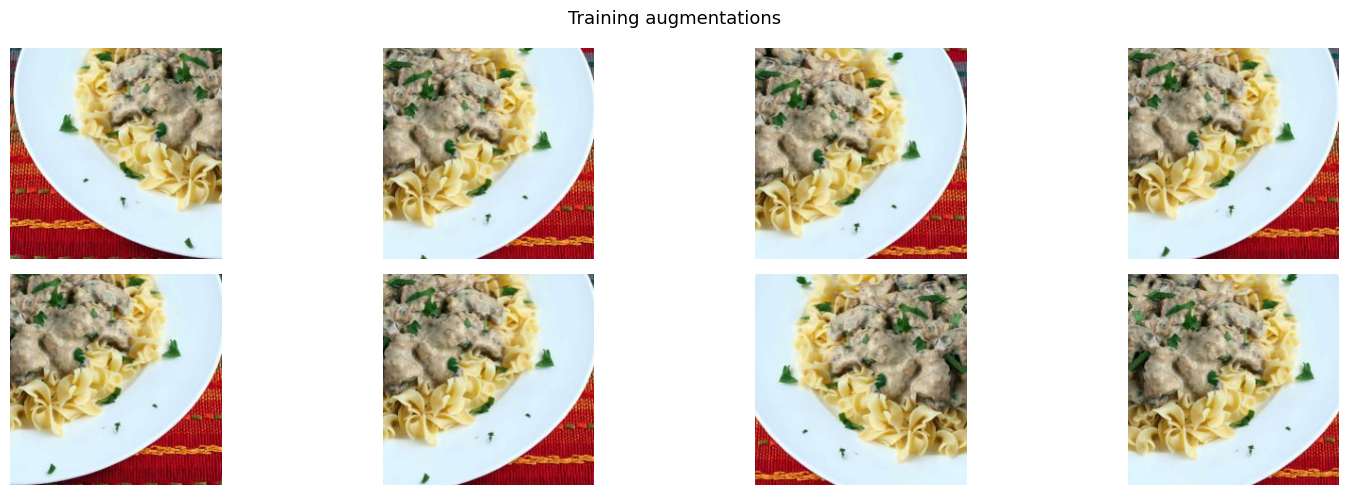

In [ ]:
sample_path = dm.train_df["path"].iloc[0]
show_augmentations(sample_path, n=8)

In [ ]:
train_loader = dm.train_dataloader()
imgs, labels = next(iter(train_loader))
print("batch shape:", imgs.shape)
print("label range:", labels.min().item(), labels.max().item())
print("pixel range:", imgs.min().item(), imgs.max().item())

batch shape: torch.Size([64, 3, 224, 224])
label range: 0 249
pixel range: -2.1179039478302 2.640000104904175


## Model architecture

Plan for the custom CNN, written down before implementing it so the
shapes are clear beforehand.

| Layer   | Operation                                  | Output channels | Output size |
|---------|--------------------------------------------|-----------------|-------------|
| Input   | -                                          | 3               | 224 x 224   |
| Block 1 | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2  | 32              | 112 x 112   |
| Block 2 | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2  | 64              | 56 x 56     |
| Block 3 | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2  | 128             | 28 x 28     |
| Block 4 | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2  | 256             | 14 x 14     |
| Block 5 | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2  | 256             | 7 x 7       |
| GAP     | Global average pooling                     | 256             | 1 x 1       |
| Dropout | Dropout on the feature vector              | 256             | -           |
| Linear  | Fully connected to number of classes       | 251             | -           |

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x


class FoodCNN(nn.Module):
    def __init__(self, num_classes=251, dropout=0.3):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.block5 = ConvBlock(256, 256)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

## Building the model and checking the output shape

Before training anything, we run a dummy batch through the model just to
confirm the shapes are correct end to end.

In [ ]:
model = FoodCNN(num_classes=CFG["num_classes"], dropout=CFG["dropout"])
count_parameters(model)

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG["img_size"], CFG["img_size"])
    out = model(dummy)
    print("output shape:", out.shape)   # expected [2, 251]

trainable parameters: 1,044,475 (1.04M)
output shape: torch.Size([2, 251])


## Wrapping the model for Lightning

In [ ]:
lit_model = FoodClassifier(
    model=model,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

## Callbacks and trainer setup

Checkpoint saves the two best models based on validation accuracy, early
stopping ends training if val accuracy does not improve for 10 straight epochs, and the logger writes metrics to a csv file we can plot later.
Logs go on Drive so they survive a session restart, unlike the dataset
which stays local.

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

LOG_DIR = f"{PROJECT_DIR}/logs/base_net"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"{LOG_DIR}/checkpoints",
    filename="epoch={epoch:02d}-val_acc={val_acc:.4f}",
    monitor="val_acc",
    mode="max",
    save_top_k=2,
)

early_stop_cb = EarlyStopping(
    monitor="val_acc",
    patience=10,
    min_delta=0.005,
    mode="max",
)

logger = CSVLogger(save_dir=LOG_DIR, name="", version="")

trainer = L.Trainer(
    max_epochs=CFG["max_epochs"],
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=logger,
    accelerator="auto",
    log_every_n_steps=20,
)

print("device:", trainer.strategy.root_device)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


device: cuda:0


## Training

In [ ]:
trainer.fit(lit_model, datamodule=dm)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


train images: 96326
val images: 16999
test images: 11994


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ FoodCNN          │  1.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.0 M                                                                                                
Total estimated model params size (MB): 4.178                                                                      
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

## Loading the best checkpoint and evaluating on test data

In [ ]:
best_ckpt = checkpoint_cb.best_model_path
print("best checkpoint:", best_ckpt)

eval_model = FoodCNN(num_classes=CFG["num_classes"], dropout=CFG["dropout"])
best_lit_model = FoodClassifier.load_from_checkpoint(best_ckpt, model=eval_model)
best_lit_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

best checkpoint: /content/drive/.shortcut-targets-by-id/1ETW9S0ElOw-z28eqFj5-Yz8hKfDYZLm1/food-project/logs/base_net/checkpoints/epoch=epoch=43-val_acc=val_acc=0.4477.ckpt


In [ ]:
test_loader = dm.test_dataloader()
y_true, y_pred = predict_all(best_lit_model.model, test_loader, device=device)

metrics = evaluate(y_true, y_pred, verbose=True)

metrics["experiment"] = "base_net"
metrics["config"] = CFG

import json
os.makedirs(LOG_DIR, exist_ok=True)
with open(f"{LOG_DIR}/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)


accuracy : 0.531
macro_precision : 0.5216
macro_recall : 0.5134
macro_f1 : 0.5061
weighted_f1 : 0.5255


Precision and recall are close here, 0.5216 vs 0.5134. BaseNet never really overfits.
Weighted F1 (0.5255) sitting right next to macro F1 (0.5061) means no big class imbalance.

## Training curves and confusion matrix

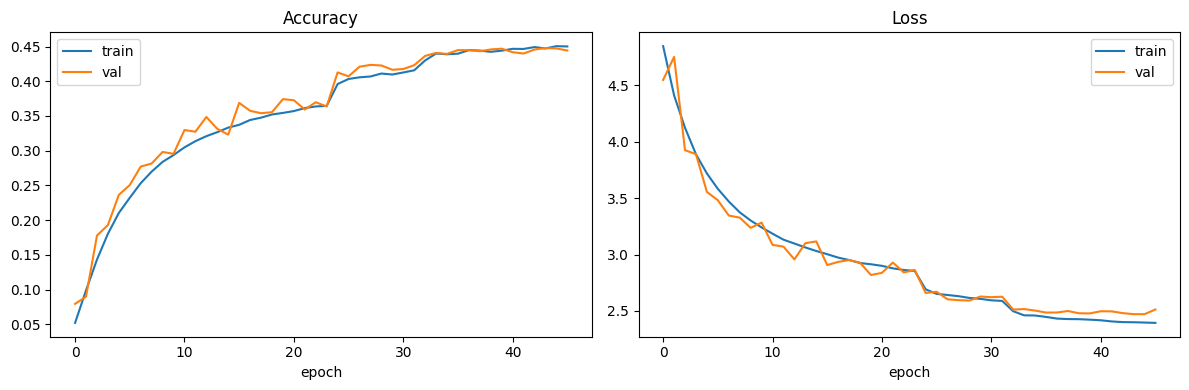

In [ ]:
plot_training_curves(LOG_DIR)

Train and val accuracy stay close for the whole run, so the model isn't overfitting in any obvious way. Loss tells the same story until around epoch 30, where train keeps dropping toward 2.4 while val flattens near 2.5. The accuracy curve is basically flat after epoch 35, sitting around 0.44-0.45, which matches the val_acc=0.4477 saved at the best checkpoint.

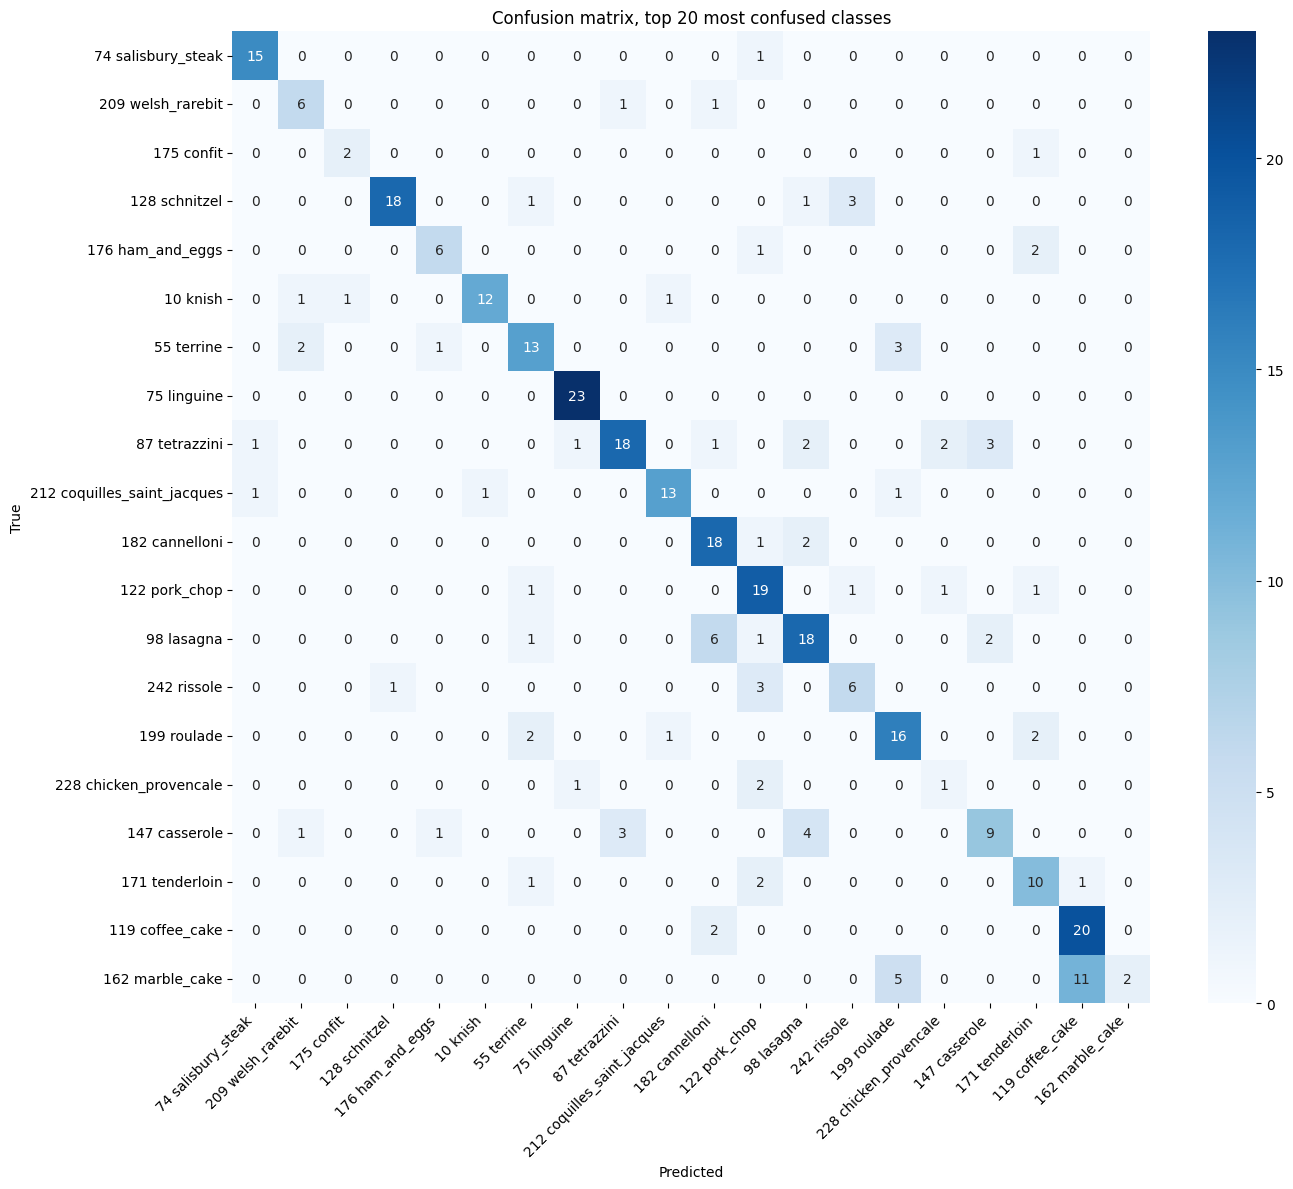

In [ ]:
class_names_path = f"{CFG['data_dir']}/class_list.txt"
class_names = None
if os.path.exists(class_names_path):
    with open(class_names_path) as f:
        class_names = [line.strip() for line in f.readlines()]

plot_confusion_matrix(y_true, y_pred, class_names=class_names, top_n=20)

The diagonal is strong for most of these classes, so the model separates them cleanly once you're past the harder cases. Salisbury steak, linguine, and coffee cake are basically clean.

The real confusion clusters around visually similar dishes. Marble cake is the worst case, only 2 out of ~18 correct, mostly confused with coffee cake and roulade, both of which are also cake-like baked goods with a similar crumb and color. Lasagna, cannelloni, and pork chop bleed into each other a bit too, which makes sense since they're plated similarly and share sauce/cheese coloring. Casserole spreads its errors across several classes, going to coquilles saint jacques, chicken provencale, and welsh rarebit, suggesting it doesn't have a strong distinguishing visual signature the model has learned yet.

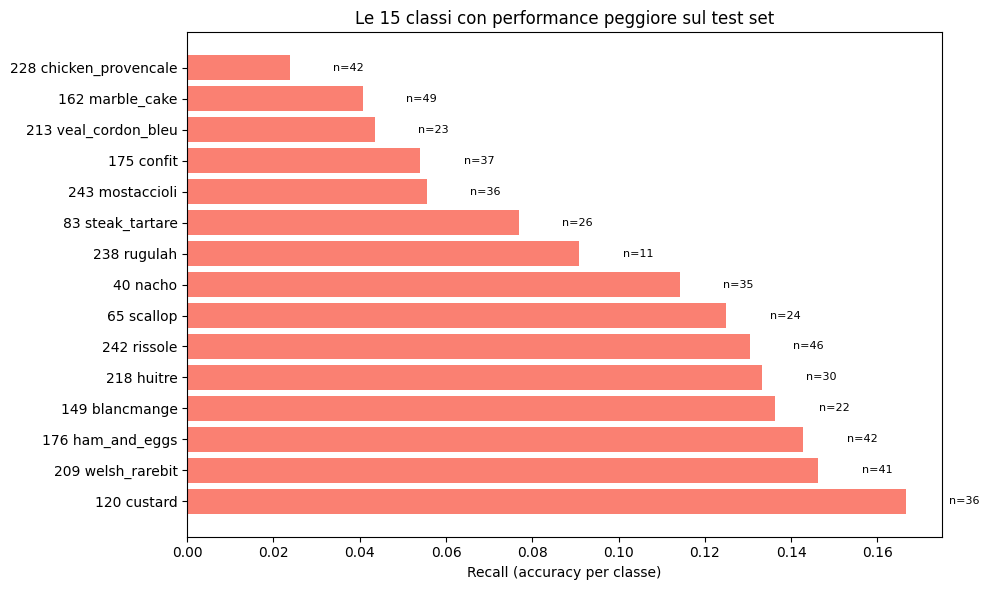

,label,class_name,precision,recall,f1,n_samples
228,228,228 chicken_provencale,0.071429,0.023810,0.035714,42
162,162,162 marble_cake,1.000000,0.040816,0.078431,49
213,213,213 veal_cordon_bleu,0.125000,0.043478,0.064516,23
175,175,175 confit,0.181818,0.054054,0.083333,37
243,243,243 mostaccioli,0.117647,0.055556,0.075472,36
83,83,83 steak_tartare,0.500000,0.076923,0.133333,26
238,238,238 rugulah,0.071429,0.090909,0.080000,11
40,40,40 nacho,0.235294,0.114286,0.153846,35
65,65,65 scallop,0.230769,0.125000,0.162162,24
242,242,242 rissole,0.272727,0.130435,0.176471,46


In [ ]:
per_class_df = per_class_metrics(y_true, y_pred, class_names=class_names)
plot_worst_classes(per_class_df, n=15)
per_class_df.head(15)

Chicken provencale sits at the bottom with recall under 0.03, which lines up with the confusion matrix, where it barely showed up on the diagonal and its errors scattered into several other classes. Marble cake and veal cordon bleu come right after, both under 0.05, and marble cake we already know struggles from low training data.

Sample size doesn't explain most of this list though. Rugulah has only 11 test samples, but nacho and confit have 35-37 and are still stuck in the same low range, so this is more about visual ambiguity than data scarcity for most of these classes.

Several of these are foods that photograph very differently depending on preparation and plating, ham and eggs, welsh rarebit, blancmange, huitre, which likely makes them harder for a relatively shallow model like BaseNet to pin down with consistent visual features.

In [ ]:
# Unassign the runtime in order to not waste paid computing units
from google.colab import runtime
runtime.unassign()